# Singular Value Decomposition (SVD), Image Compression, and Principal Component Analysis (PCA)

In this lecture notes, we will cover singular value decomposition (SVD), Image compression, and Principal Component Analysis (PCA).

### Learning Objectives:
- Understand image pixels, resolution, and their relations.
- Should be able to install and use opencv for image tasks.
- Should be able to use Numpy to do singular value decomposition.
- 

## Images

In the next block, I first show that we can use opencv to get some high-resolution images from low-resolution images. 

- High resolution (high quality): large number of pixels
- Low resolution (low quality): small number of pixels

We will use another library called 'OpenCV', which is a library for image process. Please install the library first

```
pip install opencv-python
```

In [32]:
import cv2
from tensorflow.keras import datasets, layers, models



((32, 32, 3), (512, 512, 3))

Text(0.5, 1.0, 'High Resolution')

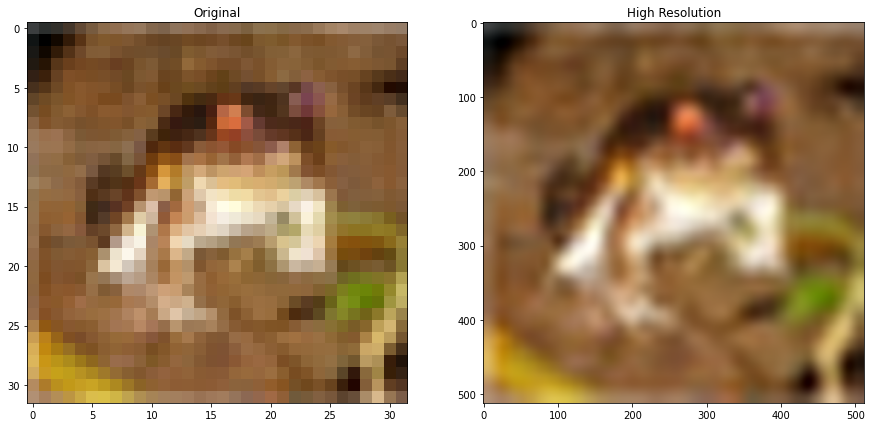

In [35]:
# show images


Let me read another clear image, which definitely has large pixel numbers.

(1200, 1800, 3)


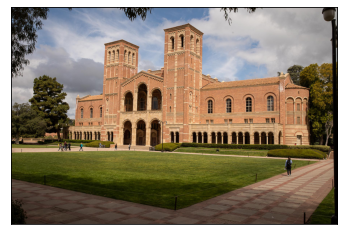

In [38]:
import numpy as np
import PIL
import urllib

url = 'https://raw.githubusercontent.com/liaochunyang/PIC16/refs/heads/main/PIC16A/images/royce.JPG'

# read image from a given url
royce = np.array( PIL.Image.open( urllib.request.urlopen(url) ) )

# print shape
print(royce.shape)

# show image
plt.imshow(royce)
plt.xticks([])
plt.yticks([])
plt.show()

#### Task: Sharing a high-resolution image

Suppose I send the royce image, I need to send $1200 * 1800 * 3 = 6,480,000$ pixel values (around 6 million). This is not the bits in the memory. 

Question: Is it possible to compress the image? Compression means reducing the number of pixels without losing important information.

# Singular Value Decomposition (SVD)

Singular Value Decomposition (SVD) is a powerful linear algebra tool. The goal of this lecture is introducing SVD, computing SVD using Python, and show one application of SVD.

In the next lecture, we will discuss Principal Component Analysis (PCA) which is a standard method in dimension reduction. SVD is used to compute PCA, which motivates us to look SVD here.

## Singular value decomposition

The singular value decomposition of an $m\times n$ matrix $A$ is a factorization of the form

$$ M = U\Sigma V^T$$

where $U$ is an $m\times m$ unitary matrix, $\Sigma$ is an $m\times n$ rectangular diagonal matrix with non-negative real numbers on the diagonal, $V$ is an $n\times n$ unitary matrix.

**Unitary matrix:** $U$ is a unitary matrix if $U^T = U^{-1}$.

P.S. If you have learned eigenvalue decomposition before, SVD is a generalization of eigen-decomposition.

In [39]:
import numpy as np

In [40]:
# Example 1


[[-0.38268343 -0.92387953]
 [-0.92387953  0.38268343]]

[5.82842712 0.17157288]

[[-0.38268343 -0.92387953  0.        ]
 [-0.92387953  0.38268343  0.        ]
 [ 0.          0.          1.        ]]


True

In [48]:
# Example 2


[[-0.37717224  0.15622986  0.23670068 -0.88164966]
 [-0.91057434 -0.06471253 -0.27101021  0.30531973]
 [-0.15622986 -0.37717224  0.88164966  0.23670068]
 [-0.06471253  0.91057434  0.30531973  0.27101021]]

[5.91359136 1.01461187]

[[-0.38268343 -0.92387953]
 [ 0.92387953 -0.38268343]]
True


We could also set `full_matrices=False` in above, which does not change our result, see the following example:

In [50]:
# Example 1


[[-0.38268343 -0.92387953]
 [-0.92387953  0.38268343]]

[5.82842712 0.17157288]

[[-0.38268343 -0.92387953  0.        ]
 [-0.92387953  0.38268343  0.        ]]
True


It means that some columns of U or some rows of V has no contribution. 

## Image Compression

In [ ]:
# since directly image reading images from URL is not supported any more due to matplotlib version update, 
# the following code may raise error message
maru = imread("https://i.pinimg.com/originals/0e/d0/23/0ed023847cad0d652d6371c3e53d1482.png")
plt.imshow(maru)

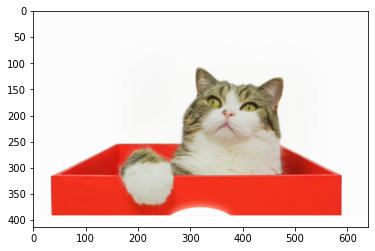

In [51]:
# if above cell does not work, try this code instead
import PIL
import urllib
url = "https://i.pinimg.com/originals/0e/d0/23/0ed023847cad0d652d6371c3e53d1482.png"
maru = np.array(PIL.Image.open(urllib.request.urlopen(url)))
plt.imshow(maru)

(-0.5, 639.5, 412.5, -0.5)

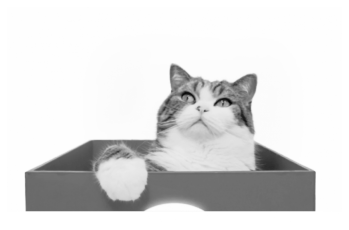

In [52]:
def to_greyscale(im):
    return 1 - np.dot(im[...,:3], [0.2989, 0.5870, 0.1140])

grey_maru = to_greyscale(maru)
plt.imshow(grey_maru, cmap = "Greys")
plt.gca().axis("off")

In [53]:
def reconstruct(gs, k):
    pass

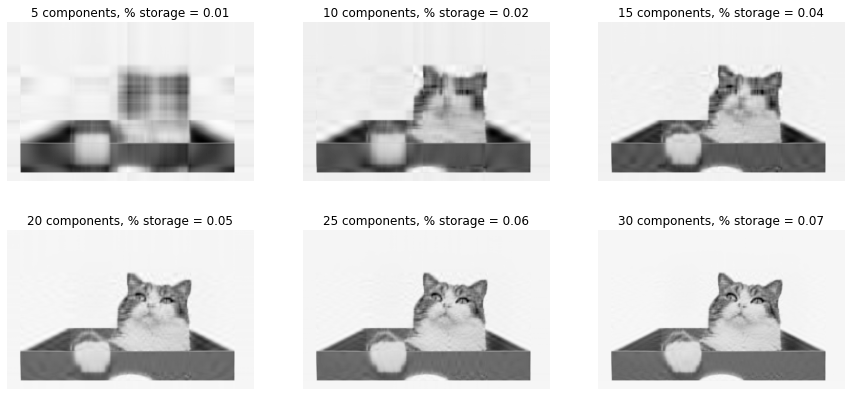

Let's do math. 

Suppose I have a general 2D numpy array ($m*n$), then I will send mn pixels. In the grey_maru case, I will send $413*640$ pixels.

When we do SVD and send the first k pricipal components (k <= min(m,n)), then I only need to send $k + mk + nk = k(m+n+1)$. 

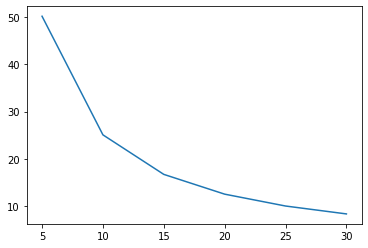

# Principal Component Analysis (PCA)

### Unsupervised Learning

Unsupervised learning in artificial intelligence is a type of machine learning that learns from data without human supervision. Unlike supervised learning, unsupervised machine learning models are given unlabeled data and allowed to discover patterns and insights without any explicit guidance or instruction.

**Dimension reduction** and **Clustering** are two fundamental unsupervised learning problems. In this lecture, we will learn PCA which is one dimension reduction technique.

**Dimension reduction:** The ambient dimension of the datapoints $x^{(1)}, \dots, x^{(m)} \in \mathbb{R}^d$ far exceeds their number, i.e. $d\gg m$. Thus, one instantly faces some computational obstacles—for a start, determining one of these pairwise distances ($\|x^{(i)}-x^{(j)}\|_2$) exactly has a high cost proportional to $d$. Dimension reduction reduces the dimension $d$.

### Dimension Reduction

**Dimensionality reduction** is the process of reducing the number of features or variables in a dataset while preserving the most important information. Techniques such as Principal Component Analysis (PCA) transform high-dimensional data into a lower-dimensional representation that is easier to analyze and visualize. Dimensionality reduction is important because high-dimensional data often increases computational cost, storage requirements, and noise, and may lead to overfitting in machine learning models. By reducing the number of dimensions, we can improve efficiency, simplify data analysis, and better visualize complex datasets.

We have done dimension reduction in several places:
- Feature selection. I showed that using a subset of features can even lead to better model performance (linear regression: insurance dataset)

- K-nearest neighbors: It fails in high-dimensional space.

- Text classification: visualize text embeddings in a 2D space (data visualization).


## Principal Component Analysis (PCA)

PCA is a popular technique in dimension reduction. It is closely related to eigendecomposition and singular value decomposition.

**PCA:** The idea of PCA is simple — reduce the number of variables $d$, while preserving as much information as possible.

Statistical explanation: Principal components are a sequence of projections of the data, mutually uncorrelated and ordered in variance. See this page: https://builtin.com/data-science/step-step-explanation-principal-component-analysis

Mathematical explanation: Principal components analysis projects all data point $x^{(i)}$ to a k-dimensional subspace such that the total distance between $x^{(i)}$ and projected $x^{(i)}$ is as small as possible. See picture below
![](https://raw.githubusercontent.com/liaochunyang/PIC16/refs/heads/main/PIC16B/03_Numerical_Linear_Algebra/pca.png)
Picture is taken from book: "The Elements of Statistical Learning - Data Mining, Inference, and Prediction", Second edition by Trevor Hastie, Robert Tibshirani, and Jerome Friedman.

### Math Description

PCA aims to project the high-dimensional data to the optimal k-dimensional hyperplane while preserving as much variance in the data as possible. We can write it as an optimization problem as well.

### Statistical Description

From a statistical perspective, Principal Component Analysis (PCA) assumes that directions with higher variance contain more important information about the data. PCA therefore finds the directions (principal components) along which the data varies the most and projects the data onto these directions while preserving as much variance as possible.


There is a method `sklearn.decomposition.PCA`, but let's do PCA using linear algebra.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# read data
data = load_iris()
X = data.data
y = data.target

# Step by step PCA

#### Step 1: Standardization 

- The range of variables is calculated and standardized in this process to analyze the contribution of each variable equally.

- Calculating the initial variables will help you categorize the variables that are dominating the other variables of small ranges.

- Formula: for each feature, minus mean and then divided by standard deviation

#### Step 2: SVD

#### Step 3: Create new features and visualize

new features are created by using singular vectors V as coefficients

In [ ]:
target_name = ['setosa', 'versicolor', 'virginica']
for label in np.unique(y):
    plt.scatter(X_pca[y==label, 0], X_pca[y==label, 1], label=target_name[label])
    plt.legend()
    
plt.xlabel('first component')
plt.ylabel('second component')
plt.show()

## Sklearn

Comments: sklearn.decomposition.PCA does not normalize data

### Why standardization?

The reason is that PCA uses variance and assumes that each column has the same variance.

In [ ]:
import pandas as pd
df = pd.read_csv("spotify_processed.csv")
df

In [ ]:
spotify = df.to_numpy()
from sklearn.decomposition import PCA

pca = PCA(n_components=5,svd_solver='full')
spotify_PCA = pca.fit_transform(spotify)
print(pca.explained_variance_ratio_)

In [ ]:
spotify_standard = (spotify - np.mean(spotify,axis=0))/np.std(spotify,axis=0)

pca = PCA(n_components=5,svd_solver='full')
spotify_PCA = pca.fit_transform(spotify_standard)
print(pca.explained_variance_ratio_)

# Disadvantages of PCA:

It is a linear method in the sense that we are finding best linear approximation. It does not work for nonlinear structure. To overcome this issue, we can do kernel PCA or other dimension reduction techniques (locally linear embedding)

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

/Applications/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  # This is added back by InteractiveShellApp.init_path()


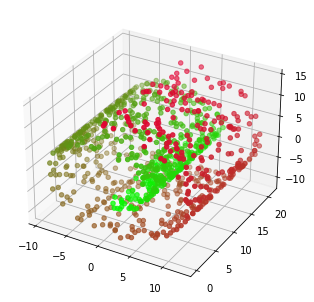

In [62]:
# Generate swiss_roll dataset

from sklearn.datasets import make_swiss_roll

X, t = make_swiss_roll(n_samples=1000, noise=0.0)

# visualize the datapoints
pix = (t-np.min(t))/(np.max(t)-np.min(t)) 
color = np.column_stack( (0.9*pix, 1-pix, 0.2*pix ) )
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],X[:,2],c=color)

Text(0.5, 1.0, 'Locally Linear Embedding')

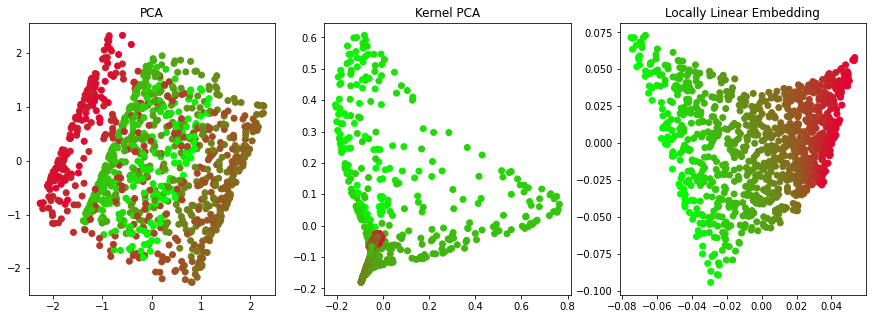

In [86]:
# PCA
from sklearn.decomposition import PCA




# kernel PCA
from sklearn.decomposition import KernelPCA



# Locally Linear Embedding
from sklearn.manifold import LocallyLinearEmbedding
